# Исследование связей между переменными

Во многих исследованиях нас интересует не отдельный показатель, а связь между несколькими переменными.

В этом ноутбуке мы научимся:

- визуально исследовать связи
- рассчитывать коэффициенты корреляции
- проверять статистическую значимость связи
- интерпретировать результаты анализа

## Импорт библиотек

In [1]:
#%pip install seaborn

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

## Что такое связь между переменными?

Связь существует тогда, когда изменение одной переменной сопровождается изменением другой.

In [3]:
experience = np.array(
    [1,2,3,4,5,6,7,8,9,10]
)

salary = np.array(
    [40,42,48,50,55,58,63,67,71,75]
)

## Диаграмма рассеивания

Первый шаг исследования связи – визуализация данных.

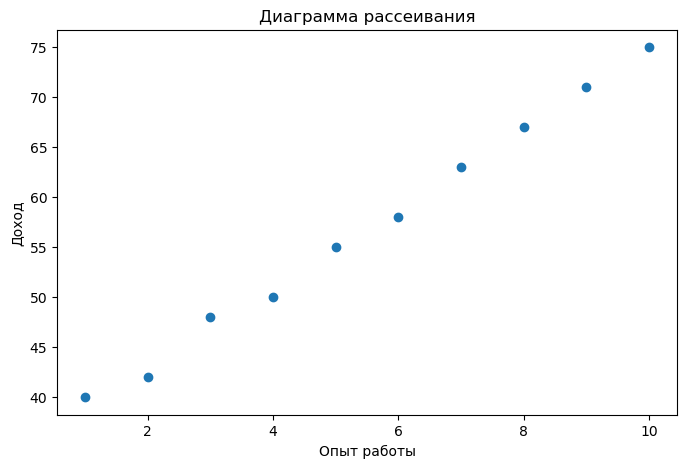

In [4]:
plt.figure(figsize=(8,5))

plt.scatter(
    experience,
    salary
)

plt.xlabel("Опыт работы")
plt.ylabel("Доход")
plt.title("Диаграмма рассеивания")

plt.show()

Каждая точка соответствует одному наблюдению. По форме облака точек часто можно предварительно понять характер связи.

**Возможные варианты связи**

- Положительная связь – при увеличении одной переменной увеличивается другая
- Отрицательная связь – при увеличении одной переменной другая уменьшается
- Отсутствие связи – изменение одной переменной не сопровождается систематическим изменением другой
- Нелинейная связь – связь существует, но не описывается прямой линией

## Коэффициент корреляции Пирсона

Коэффициент корреляции Пирсона измеряет силу линейной связи между двумя количественными переменными. Он принимает значение из диапазона [-1 ; 0]. Абсолютная отрицательная (обратная) связь обозначается как -1. Ноль означает отсутствие связи. Абсолютная положительная связь обозначается как 1. 

In [5]:
r, p_value = stats.pearsonr(
    experience,
    salary
)

print(f"r = {r:.3f}")
print(f"p-value = {p_value:.5f}")

r = 0.998
p-value = 0.00000


### Интерпретация коэффициента

| r           | Интерпретация |
| ----------- | ------------- |
| 0.00 – 0.19 | очень слабая  |
| 0.20 – 0.39 | слабая        |
| 0.40 – 0.59 | умеренная     |
| 0.60 – 0.79 | сильная       |
| 0.80 – 1.00 | очень сильная |


Например, если r = 0.998, можно сделать вывод об очень сильной положительной линейной связи между переменными.

### Проверка статистической значимости

Даже если коэффициент корреляции отличается от нуля, необходимо проверить, не является ли это результатом случайности.

В данном случае мы проверяем гипотезы:

$$
H_0: \rho = 0
$$

$$
H_1: \rho \ne 0
$$


In [6]:
alpha = 0.05

if p_value <= alpha:
    print("Связь статистически значима")
else:
    print("Нет оснований считать связь значимой")

Связь статистически значима


## Корреляция Спирмена

Корреляция Пирсона хорошо работает для линейных зависимостей. Если данные измерени по достаточно низкой шкале, содержат выбросы или иным образом нарушают предпосылки, используют коэффициент Спирмена.

In [7]:
rho, p_value = stats.spearmanr(
    experience,
    salary
)

print(f"rho = {rho:.3f}")
print(f"p-value = {p_value:.5f}")

rho = 1.000
p-value = 0.00000


Какой коэффициент выбрать?

| Ситуация              | Метод   |
| --------------------- | ------- |
| Количественные данные | Пирсон  |
| Порядковые данные     | Спирмен |
| Есть выбросы          | Спирмен |
| Линейная связь        | Пирсон  |
| Монотонная связь      | Спирмен |


## Корреляционная матрица

Когда переменных много, рассчитывать коэффициенты корреляции попарно неудобно.

Для этого используется корреляционная матрица.

In [14]:
df = pd.DataFrame({
    "age": [22,25,28,35,40],
    "income": [40,50,55,70,80],
    "experience": [10,3,2,10,7]
})

**Построим корреляционную матрицу**

На диагональной оси мы увидим единицы – связь переменной с самой собой абсолютна. В остальных ячейках мы видим попарные значения коэффициента корреляции между переменными. 

In [15]:
corr_matrix = df.corr(
    numeric_only=True
)

corr_matrix

,age,income,experience
age,1.000000,0.996712,0.188059
income,0.996712,1.000000,0.132480
experience,0.188059,0.132480,1.000000


**Тепловая карта**, построенная на основе значений коэффициента корреляции, часто используется для визуализации корреляционной матрицы.

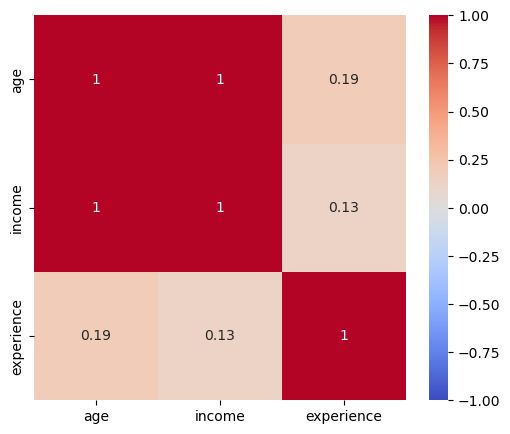

In [16]:
plt.figure(figsize=(6,5))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)

plt.show()

Тепловая карта позволяет быстро находить сильные положительные и отрицательные связи.